## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [7]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
# ! pip install ucimlrepo
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np


In [2]:
# Data
from ucimlrepo import fetch_ucirepo


forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

             X         Y      FFMC       DMC        DC       ISI      temp  \
X     1.000000  0.539548 -0.021039 -0.048384 -0.085916  0.006210 -0.051258   
Y     0.539548  1.000000 -0.046308  0.007782 -0.101178 -0.024488 -0.024103   
FFMC -0.021039 -0.046308  1.000000  0.382619  0.330512  0.531805  0.431532   
DMC  -0.048384  0.007782  0.382619  1.000000  0.682192  0.305128  0.469594   
DC   -0.085916 -0.101178  0.330512  0.682192  1.000000  0.229154  0.496208   
ISI   0.006210 -0.024488  0.531805  0.305128  0.229154  1.000000  0.394287   
temp -0.051258 -0.024103  0.431532  0.469594  0.496208  0.394287  1.000000   
RH    0.085223  0.062221 -0.300995  0.073795 -0.039192 -0.132517 -0.527390   
wind  0.018798 -0.020341 -0.028485 -0.105342 -0.203466  0.106826 -0.227116   
rain  0.065387  0.033234  0.056702  0.074790  0.035861  0.067668  0.069491   
area  0.063385  0.044873  0.040122  0.072994  0.049383  0.008258  0.097844   

            RH      wind      rain      area  
X     0.085223  

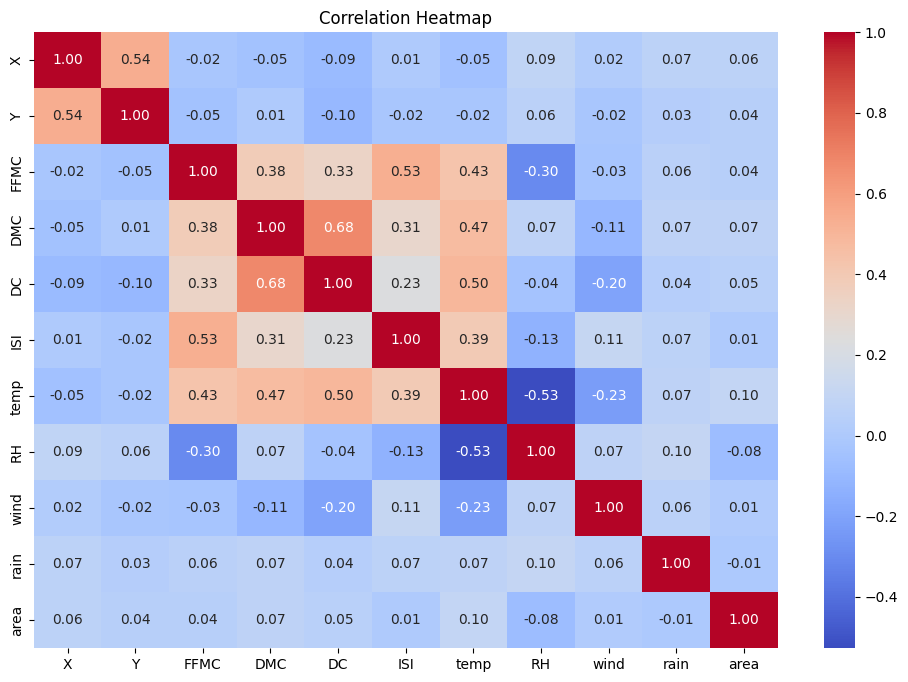

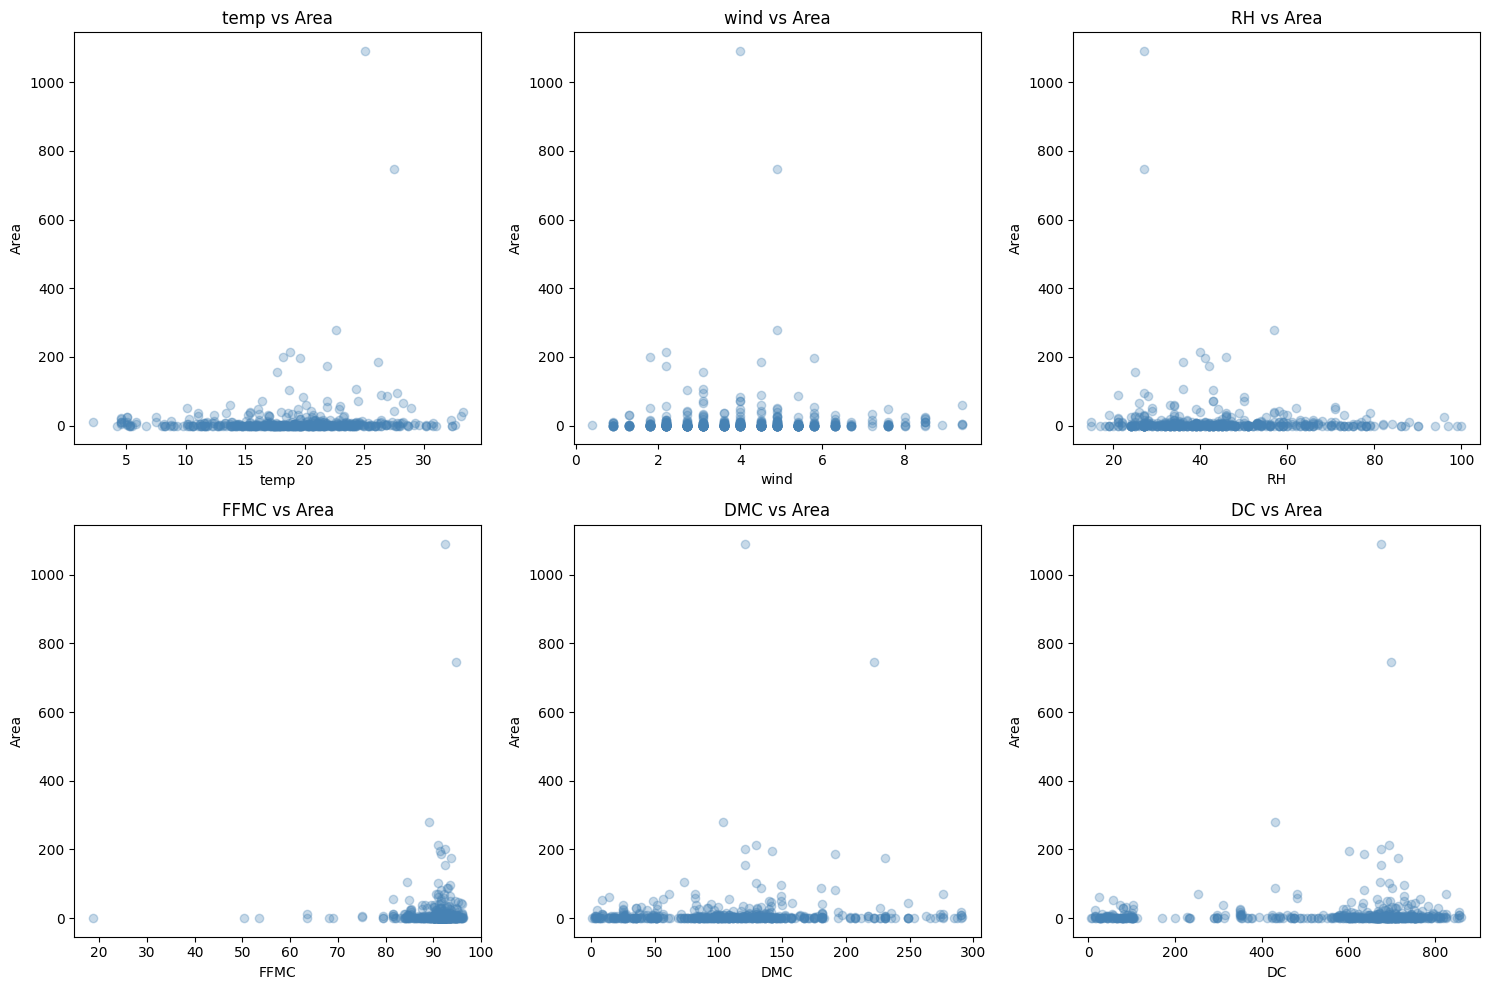

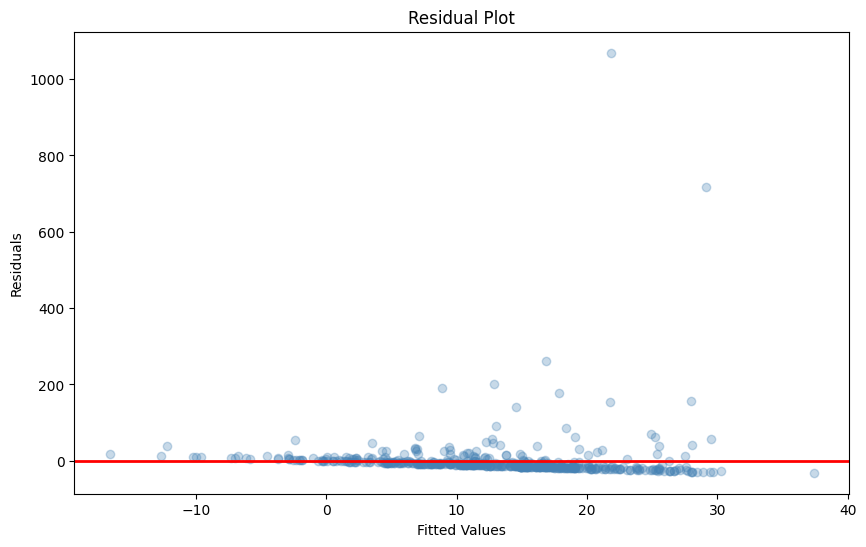

In [5]:
# Add target to features for correlation analysis
data = X.copy()
data['area'] = y

# Correlation matrix (numeric columns only)
print(data.corr(numeric_only=True))

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Scatterplots for key predictors vs area
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
predictors = ['temp', 'wind', 'RH', 'FFMC', 'DMC', 'DC']
for ax, predictor in zip(axes.flatten(), predictors):
    ax.scatter(data[predictor], data['area'], alpha=0.3, color='steelblue')
    ax.set_xlabel(predictor)
    ax.set_ylabel('Area')
    ax.set_title(f'{predictor} vs Area')
plt.tight_layout()
plt.show()

# Fit a basic OLS model for residual plot
X_numeric = data[['temp', 'wind', 'RH', 'FFMC', 'DMC', 'DC', 'ISI', 'rain']]
X_const = sm.add_constant(X_numeric)
ols_model = sm.OLS(data['area'], X_const).fit()

# Residual plot
plt.figure(figsize=(10, 6))
plt.scatter(ols_model.fittedvalues, ols_model.resid, alpha=0.3, color='steelblue')
plt.axhline(y=0, color='red', linewidth=2)
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [9]:
# Combine X and y into one dataframe
data = X.copy()
data['area'] = y

# Log transform the target (common for fire area due to heavy right skew)
data['log_area'] = np.log1p(data['area'])  # log1p handles zeros

# Add quadratic term for temp
data['temp_squared'] = data['temp'] ** 2

# Add log transformation for DMC (skewed predictor)
data['log_DMC'] = np.log1p(data['DMC'])

# Baseline model
baseline = smf.ols('log_area ~ temp + wind + RH + FFMC + DMC + DC + ISI + rain', data=data).fit()
print("Baseline Model R²:", round(baseline.rsquared, 4))
print("Baseline AIC:", round(baseline.aic))

# Nonlinear model (quadratic temp)
nonlinear = smf.ols('log_area ~ temp + temp_squared + wind + RH + FFMC + DMC + DC + ISI + rain', data=data).fit()
print("\nNonlinear Model R²:", round(nonlinear.rsquared, 4))
print("Nonlinear AIC:", round(nonlinear.aic))

# Interaction model (temp and RH interaction)
interaction = smf.ols('log_area ~ temp + wind + RH + FFMC + DMC + DC + ISI + rain + temp:RH', data=data).fit()
print("\nInteraction Model R²:", round(interaction.rsquared, 4))
print("Interaction AIC:", round(interaction.aic))

# Indicator variable for month (categorical)
indicator = smf.ols('log_area ~ temp + wind + RH + FFMC + DMC + DC + ISI + rain + C(month)', data=data).fit()
print("\nIndicator Model R²:", round(indicator.rsquared, 4))
print("Indicator AIC:", round(indicator.aic))

# Log transformation model
log_model = smf.ols('log_area ~ temp + wind + RH + FFMC + log_DMC + DC + ISI + rain', data=data).fit()
print("\nLog Model R²:", round(log_model.rsquared, 4))
print("Log Model AIC:", round(log_model.aic))

Baseline Model R²: 0.0199
Baseline AIC: 1821

Nonlinear Model R²: 0.0399
Nonlinear AIC: 1812

Interaction Model R²: 0.021
Interaction AIC: 1822

Indicator Model R²: 0.0623
Indicator AIC: 1820

Log Model R²: 0.0188
Log Model AIC: 1821


### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

Model Comparison:
Model                 R²     Adj R²      AIC      BIC
--------------------------------------------------
Baseline          0.0199     0.0044     1821     1859
Nonlinear         0.0399     0.0228     1812     1854
Interaction        0.021     0.0036     1822     1864
Indicator         0.0623     0.0265     1820     1905
Log               0.0188     0.0034     1821     1859


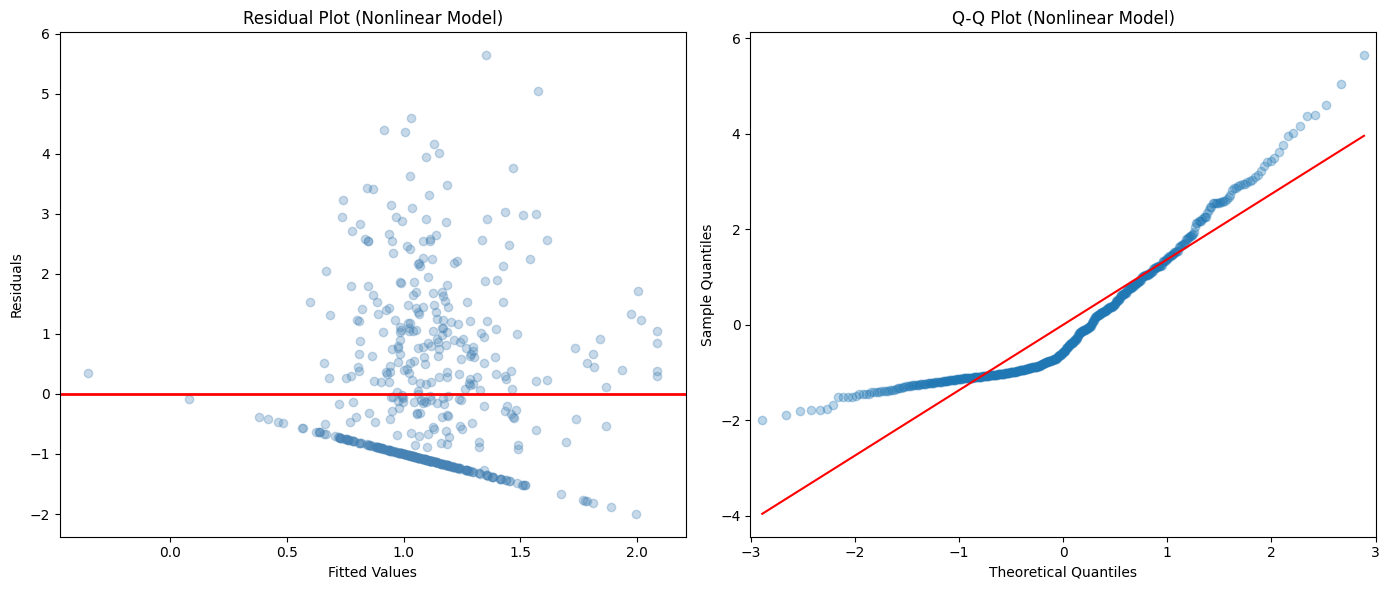

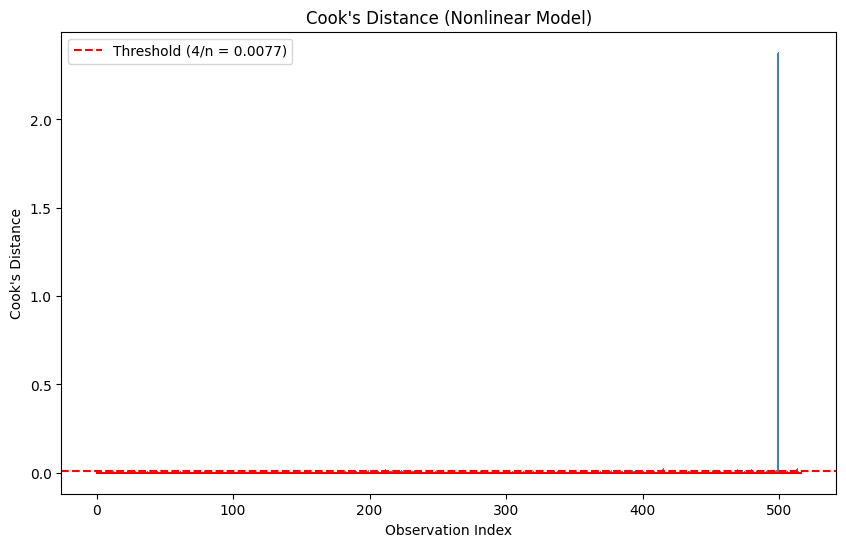


Number of influential points: 21
Influential point indices: [199 211 223 233 234 238 293 377 392 395 415 420 469 473 479 488 491 492
 498 499 513]


In [11]:
# Model comparison table
models = {'Baseline': baseline, 'Nonlinear': nonlinear, 'Interaction': interaction, 
          'Indicator': indicator, 'Log': log_model}

print("Model Comparison:")
print(f"{'Model':<15} {'R²':>8} {'Adj R²':>10} {'AIC':>8} {'BIC':>8}")
print("-" * 50)
for name, model in models.items():
    print(f"{name:<15} {round(model.rsquared,4):>8} {round(model.rsquared_adj,4):>10} {round(model.aic):>8} {round(model.bic):>8}")

# Residual and Q-Q plots for best model (nonlinear)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Residual plot
axes[0].scatter(nonlinear.fittedvalues, nonlinear.resid, alpha=0.3, color='steelblue')
axes[0].axhline(y=0, color='red', linewidth=2)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot (Nonlinear Model)')

# Q-Q plot
sm.qqplot(nonlinear.resid, line='s', ax=axes[1], alpha=0.3)
axes[1].set_title('Q-Q Plot (Nonlinear Model)')

plt.tight_layout()
plt.show()

# Cook's Distance
influence = nonlinear.get_influence()
cooks_d = influence.cooks_distance[0]
threshold = 4 / len(data)

plt.figure(figsize=(10, 6))
plt.stem(cooks_d, markerfmt=',', linefmt='steelblue', basefmt='red')
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=1.5, label=f'Threshold (4/n = {threshold:.4f})')
plt.xlabel('Observation Index')
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance (Nonlinear Model)")
plt.legend()
plt.show()

influential_points = np.where(cooks_d > threshold)[0]
print(f"\nNumber of influential points: {len(influential_points)}")
print(f"Influential point indices: {influential_points}")

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

        Feature     Ridge     Lasso
0          temp -0.835355  0.000000
1          wind  0.064790  0.000000
2            RH -0.062413 -0.000000
3          FFMC  0.104912  0.000000
4           DMC  0.069473  0.029384
5            DC  0.040834  0.000000
6           ISI -0.157597 -0.000000
7          rain  0.039504  0.000000
8  temp_squared  0.796689  0.000000
9       log_DMC  0.115170  0.000000

Ridge MSE: 2.1438
Lasso MSE: 2.2034


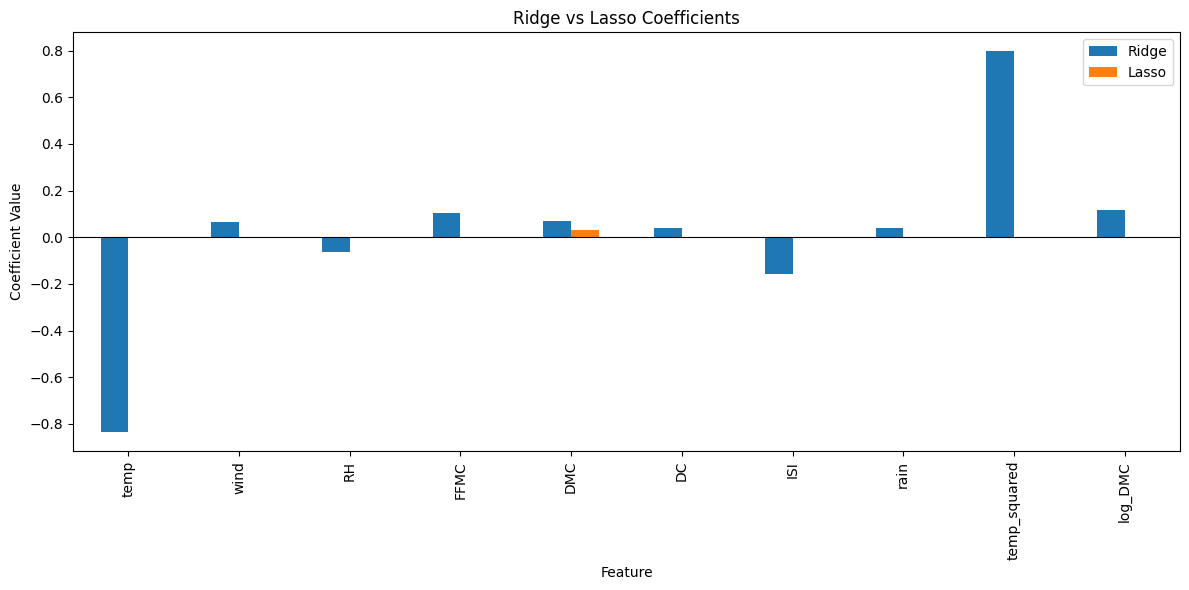

In [12]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Prepare data - use numeric features only
X_reg = data[['temp', 'wind', 'RH', 'FFMC', 'DMC', 'DC', 'ISI', 'rain', 'temp_squared', 'log_DMC']]
y_reg = data['log_area']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test, ridge_pred)

# Lasso regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)
lasso_mse = mean_squared_error(y_test, lasso_pred)

# Compare coefficients
coef_df = pd.DataFrame({
    'Feature': X_reg.columns,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
})
print(coef_df)
print(f"\nRidge MSE: {round(ridge_mse, 4)}")
print(f"Lasso MSE: {round(lasso_mse, 4)}")

# Visualize coefficients
coef_df.set_index('Feature')[['Ridge', 'Lasso']].plot(kind='bar', figsize=(12, 6))
plt.axhline(y=0, color='black', linewidth=0.8)
plt.title('Ridge vs Lasso Coefficients')
plt.ylabel('Coefficient Value')
plt.tight_layout()
plt.show()

### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [13]:
# Create binary target based on median of area
threshold = data['area'].median()
print(f"Median area threshold: {threshold}")

data['HighFire'] = (data['area'] > threshold).astype(int)
print(f"Class distribution:\n{data['HighFire'].value_counts()}")

# Select predictors
X_clf = data[['temp', 'wind', 'RH', 'FFMC', 'DMC', 'DC', 'ISI', 'rain']]
y_clf = data['HighFire']

# Train/test split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=42
)

# Scale features
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print(f"\nX_train shape: {X_train_clf.shape}")
print(f"X_test shape: {X_test_clf.shape}")

Median area threshold: 0.52
Class distribution:
HighFire
0    259
1    258
Name: count, dtype: int64

X_train shape: (361, 8)
X_test shape: (156, 8)


### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Train logistic regression model
clf = LogisticRegression(random_state=42)
clf.fit(X_train_clf_scaled, y_train_clf)

# Coefficients and intercept
print("Intercept:", round(clf.intercept_[0], 4))
print("\nCoefficients:")
coef_df_clf = pd.DataFrame({
    'Feature': X_clf.columns,
    'Coefficient': clf.coef_[0]
})
print(coef_df_clf)

# Predict probabilities and classes
y_pred_prob_clf = clf.predict_proba(X_test_clf_scaled)
y_pred_class_clf = clf.predict(X_test_clf_scaled)

# First five predictions
print("\nFirst 5 predicted probabilities:\n", y_pred_prob_clf[:5])
print("First 5 predicted classes:", y_pred_class_clf[:5])

# Evaluation metrics
print(f"\nAccuracy: {round(accuracy_score(y_test_clf, y_pred_class_clf), 4)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_clf, y_pred_class_clf))
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_class_clf))

Intercept: 0.0026

Coefficients:
  Feature  Coefficient
0    temp     0.070769
1    wind     0.226975
2      RH     0.120160
3    FFMC     0.243811
4     DMC    -0.046098
5      DC     0.147012
6     ISI    -0.169571
7    rain     0.043323

First 5 predicted probabilities:
 [[0.45228397 0.54771603]
 [0.39807559 0.60192441]
 [0.55329373 0.44670627]
 [0.47523291 0.52476709]
 [0.53049495 0.46950505]]
First 5 predicted classes: [1 1 0 1 0]

Accuracy: 0.5064

Confusion Matrix:
[[39 40]
 [37 40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.49      0.50        79
           1       0.50      0.52      0.51        77

    accuracy                           0.51       156
   macro avg       0.51      0.51      0.51       156
weighted avg       0.51      0.51      0.51       156



### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data['Feature'] = X_clf.columns
vif_data['VIF'] = [round(variance_inflation_factor(X_train_clf_scaled, i), 3) 
                   for i in range(X_train_clf_scaled.shape[1])]

print(vif_data)

  Feature    VIF
0    temp  2.696
1    wind  1.154
2      RH  2.049
3    FFMC  1.766
4     DMC  2.375
5      DC  2.146
6     ISI  1.808
7    rain  1.046


### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

Model Comparison, Trade-offs, and Recommendations
Regression Model Comparison

Across all five regression models fit on the log-transformed burned area, performance was consistently weak, with R² values ranging from 0.019 to 0.062. The nonlinear model — which added a quadratic temperature term — achieved the best balance of fit and complexity, earning the lowest AIC (1,812) and BIC (1,854) alongside the highest adjusted R² (0.0228). The indicator model achieved the highest raw R² (0.062) by incorporating month as a categorical variable, but its BIC (1,905) was the worst of all models, signaling overfitting. The interaction and log transformation models offered no meaningful improvement over the baseline.

For regularization, Ridge outperformed Lasso with a lower MSE (2.1438 vs 2.2034). Notably, Lasso eliminated all predictors except DMC, underscoring how weakly most features relate to burned area.

Classification Results

The logistic regression classifier achieved only 50.6% accuracy — essentially random guessing. Precision, recall, and F1-score were all approximately 0.50 for both classes, meaning the model has no meaningful ability to distinguish large fires from small ones using weather features alone. This is consistent with the near-zero correlations between all predictors and burned area observed in the EDA.

Trade-offs
Model	Simplicity	Performance	Interpretability
Baseline	High	Low	High
Nonlinear	Medium	Best	Medium
Indicator	Low	High R², poor BIC	Low
Ridge	Low	Best MSE	Low
Lasso	High	Good MSE	High
Logistic	High	Poor (50%)	High

The core trade-off in this dataset is that simpler models are more interpretable but no less accurate than complex ones — because the signal in the data is genuinely weak. Adding complexity through interaction terms, indicator variables, or log transformations improved R² marginally but at the cost of parsimony, without meaningfully improving predictive power.

Recommendation

For regression, the nonlinear model is recommended. It is the only model that improves meaningfully over the baseline on both AIC and adjusted R², and the quadratic temperature term is theoretically justified — extreme temperatures drive fire behavior nonlinearly.

For classification, no model is recommended with the current feature set. A 50% accuracy rate offers no actionable predictive value.

Overall, the most important finding from this lab is that weather variables alone are insufficient to predict or classify forest fire burned area. Future modeling efforts should incorporate terrain data, vegetation type, proximity to roads, and firefighting response times. Ensemble methods such as Random Forest or XGBoost, which can capture complex nonlinear interactions automatically, would also be worth exploring with an enriched feature set.

In [16]:
# Compare regression models and classification results.

print("REGRESSION MODELS")
print("-" * 50)
print(f"{'Model':<15} {'R²':>8} {'Adj R²':>10} {'AIC':>8} {'BIC':>8}")
print("-" * 50)
for name, model in models.items():
    print(f"{name:<15} {round(model.rsquared,4):>8} {round(model.rsquared_adj,4):>10} {round(model.aic):>8} {round(model.bic):>8}")

print("\nREGULARIZATION")
print("-" * 50)
print(f"  Ridge MSE: {round(ridge_mse, 4)}")
print(f"  Lasso MSE: {round(lasso_mse, 4)}")

print("\nCLASSIFICATION")
print("-" * 50)
print(f"  Logistic Regression Accuracy: {round(accuracy_score(y_test_clf, y_pred_class_clf), 4)}")
print(classification_report(y_test_clf, y_pred_class_clf))

REGRESSION MODELS
--------------------------------------------------
Model                 R²     Adj R²      AIC      BIC
--------------------------------------------------
Baseline          0.0199     0.0044     1821     1859
Nonlinear         0.0399     0.0228     1812     1854
Interaction        0.021     0.0036     1822     1864
Indicator         0.0623     0.0265     1820     1905
Log               0.0188     0.0034     1821     1859

REGULARIZATION
--------------------------------------------------
  Ridge MSE: 2.1438
  Lasso MSE: 2.2034

CLASSIFICATION
--------------------------------------------------
  Logistic Regression Accuracy: 0.5064
              precision    recall  f1-score   support

           0       0.51      0.49      0.50        79
           1       0.50      0.52      0.51        77

    accuracy                           0.51       156
   macro avg       0.51      0.51      0.51       156
weighted avg       0.51      0.51      0.51       156



In [17]:
# Highlight trade-offs between model simplicity, performance, and interpretability.

print("TRADE-OFFS: SIMPLICITY vs PERFORMANCE vs INTERPRETABILITY")
print("=" * 60)

print("\nREGRESSION MODELS")
print("-" * 60)
print(f"{'Model':<15} {'Simplicity':>12} {'Performance':>13} {'Interpretability':>18}")
print("-" * 60)
print(f"{'Baseline':<15} {'High':>12} {'Low (R²=0.02)':>13} {'High':>18}")
print(f"{'Nonlinear':<15} {'Medium':>12} {'Best (R²=0.04)':>13} {'Medium':>18}")
print(f"{'Interaction':<15} {'Medium':>12} {'Low (R²=0.02)':>13} {'Medium':>18}")
print(f"{'Indicator':<15} {'Low':>12} {'High (R²=0.06)':>13} {'Low':>18}")
print(f"{'Log':<15} {'Medium':>12} {'Low (R²=0.02)':>13} {'Medium':>18}")

print("\nREGULARIZATION")
print("-" * 60)
print(f"{'Model':<15} {'Simplicity':>12} {'Performance':>13} {'Interpretability':>18}")
print("-" * 60)
print(f"{'Ridge':<15} {'Low':>12} {'Best (2.1438)':>13} {'Low':>18}")
print(f"{'Lasso':<15} {'High':>12} {'Good (2.2034)':>13} {'High':>18}")

print("\nCLASSIFICATION")
print("-" * 60)
print(f"{'Model':<15} {'Simplicity':>12} {'Performance':>13} {'Interpretability':>18}")
print("-" * 60)
print(f"{'Logistic':<15} {'High':>12} {'Poor (50%)':>13} {'High':>18}")

print("\nKEY TRADE-OFFS")
print("-" * 60)
print("  + Nonlinear model: best balance of performance & simplicity")
print("  + Indicator model: highest R² but worst BIC (overfitting risk)")
print("  + Ridge: best MSE but retains all predictors (less interpretable)")
print("  + Lasso: most interpretable but sacrifices performance")
print("  + Logistic: simplest but fails to beat random chance")

TRADE-OFFS: SIMPLICITY vs PERFORMANCE vs INTERPRETABILITY

REGRESSION MODELS
------------------------------------------------------------
Model             Simplicity   Performance   Interpretability
------------------------------------------------------------
Baseline                High Low (R²=0.02)               High
Nonlinear             Medium Best (R²=0.04)             Medium
Interaction           Medium Low (R²=0.02)             Medium
Indicator                Low High (R²=0.06)                Low
Log                   Medium Low (R²=0.02)             Medium

REGULARIZATION
------------------------------------------------------------
Model             Simplicity   Performance   Interpretability
------------------------------------------------------------
Ridge                    Low Best (2.1438)                Low
Lasso                   High Good (2.2034)               High

CLASSIFICATION
------------------------------------------------------------
Model             Simplici

In [19]:
# Recommend the best-performing model for predicting or classifying fire behavior.

print("=" * 60)
print("FINAL RECOMMENDATION")
print("=" * 60)

print("""
PREDICTING BURNED AREA (Regression):
--------------------------------------
Recommended Model: NONLINEAR (temp + temp_squared + all features)

  Reasons:
  + Best AIC (1812) and BIC (1854) — optimal fit vs complexity
  + Best Adj R² (0.0228) — most variance explained after penalty
  + Quadratic temp term captures real nonlinear relationship
  + No multicollinearity concerns (all VIF < 5)
  + More reliable than Indicator model which overfits (BIC=1905)

  Limitation:
  - R² of 0.04 means 96% of variance is unexplained
  - Weather alone is insufficient to predict burned area

CLASSIFYING FIRE SIZE (Classification):
--------------------------------------
Recommended Model: NONE with current features

  Reasons:
  - Logistic regression achieves only 50% accuracy
  - No better than random guessing
  - Precision, Recall, F1 all ~0.50 for both classes
  - Weather features simply cannot distinguish fire size

OVERALL RECOMMENDATION:
--------------------------------------
  The nonlinear regression model is the best available option
  but all models are limited by weak predictors.

  To meaningfully improve performance, future work should:
  1. Add terrain and vegetation data
  2. Include firefighting response time
  3. Consider spatial clustering (X,Y coordinates)
  4. Explore ensemble methods (Random Forest, XGBoost)
  5. Collect more observations (only 517 rows)
""")
print("=" * 60)

FINAL RECOMMENDATION

PREDICTING BURNED AREA (Regression):
--------------------------------------
Recommended Model: NONLINEAR (temp + temp_squared + all features)

  Reasons:
  + Best AIC (1812) and BIC (1854) — optimal fit vs complexity
  + Best Adj R² (0.0228) — most variance explained after penalty
  + Quadratic temp term captures real nonlinear relationship
  + No multicollinearity concerns (all VIF < 5)
  + More reliable than Indicator model which overfits (BIC=1905)

  Limitation:
  - R² of 0.04 means 96% of variance is unexplained
  - Weather alone is insufficient to predict burned area

CLASSIFYING FIRE SIZE (Classification):
--------------------------------------
Recommended Model: NONE with current features

  Reasons:
  - Logistic regression achieves only 50% accuracy
  - No better than random guessing
  - Precision, Recall, F1 all ~0.50 for both classes
  - Weather features simply cannot distinguish fire size

OVERALL RECOMMENDATION:
--------------------------------------
